## Fashion MNIST Neural Network with Keras Sequential API

In [6]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Flatten, Dense
from sklearn.metrics import confusion_matrix, classification_report

In [7]:
## Load Dataset
(X_train, y_train), (X_test, y_test)=fashion_mnist.load_data()

print("Training images shape:", X_train.shape)
print("Training labels shape:", y_train.shape)

print("Testing images shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)


In [8]:
## Class Names
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

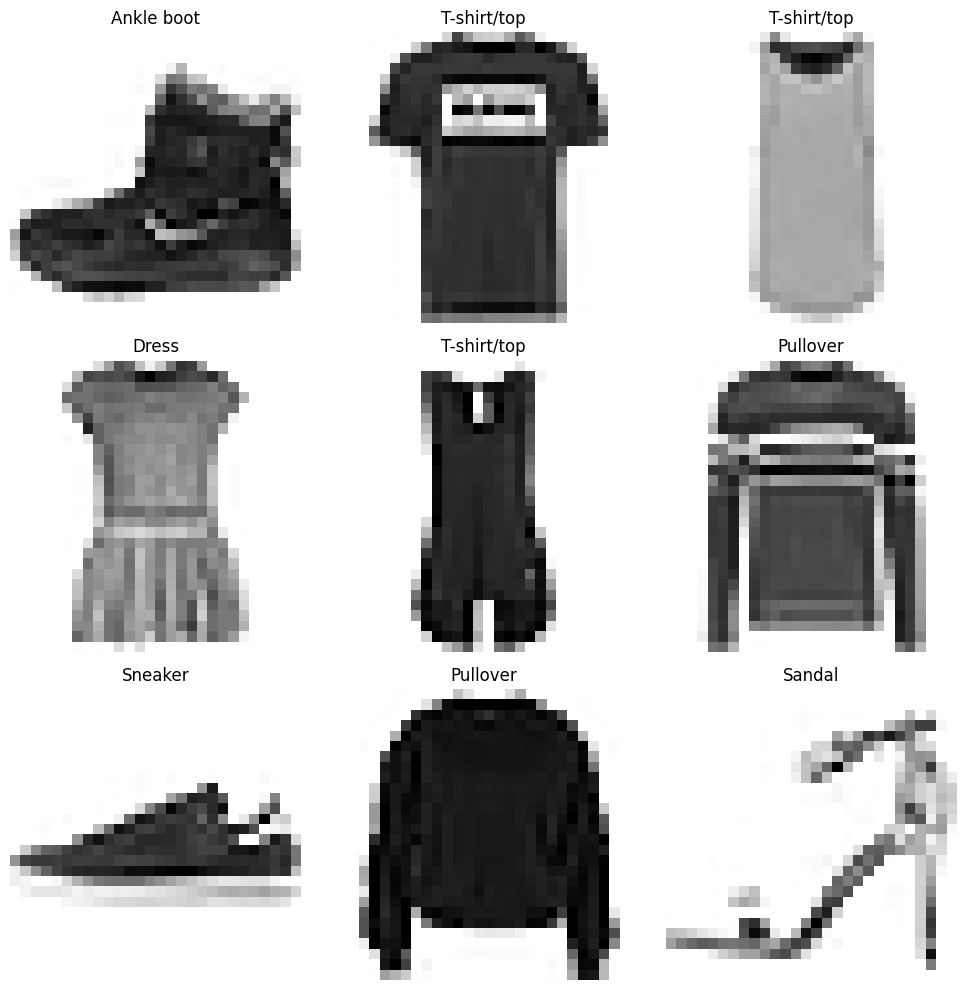

In [9]:
## Visualize Some Images
plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(X_train[i], cmap="binary")
    plt.title(class_names[y_train[i]])
    plt.axis("off")
    
plt.tight_layout()
plt.show()
    

In [10]:
# Scaling
X_train=X_train/255.0
X_test=X_test/255.0

In [11]:
# BUILD NEURAL NETWORK
model=Sequential([
    #Input layer
    InputLayer(shape=(28, 28)),
    
    # Convert 28x28 into 784
    Flatten(),
    
    # Hidden Layer 1
    Dense(300, activation="relu"),
    
    #Hidden Layer 2
    Dense(100, activation="relu"),
    
    # Output layer
    Dense(10, activation="softmax")
])

In [12]:
# model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Compile Model
model.compile(
    optimizer="adam",
    loss='sparse_categorical_crossentropy',
    metrics=["accuracy"]
)

In [14]:
# Train Model
history=model.fit(
    X_train, y_train, epochs=10, validation_data=(X_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8283 - loss: 0.4773 - val_accuracy: 0.8289 - val_loss: 0.4491
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8697 - loss: 0.3587 - val_accuracy: 0.8647 - val_loss: 0.3725
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8819 - loss: 0.3221 - val_accuracy: 0.8750 - val_loss: 0.3443
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8877 - loss: 0.3014 - val_accuracy: 0.8721 - val_loss: 0.3481
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8947 - loss: 0.2832 - val_accuracy: 0.8750 - val_loss: 0.3566
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8998 - loss: 0.2679 - val_accuracy: 0.8815 - val_loss: 0.3358
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9042 - loss: 0.2561 - val_accuracy: 0.8830 - val_loss: 0.3417
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9092 - loss: 0.2447 - 

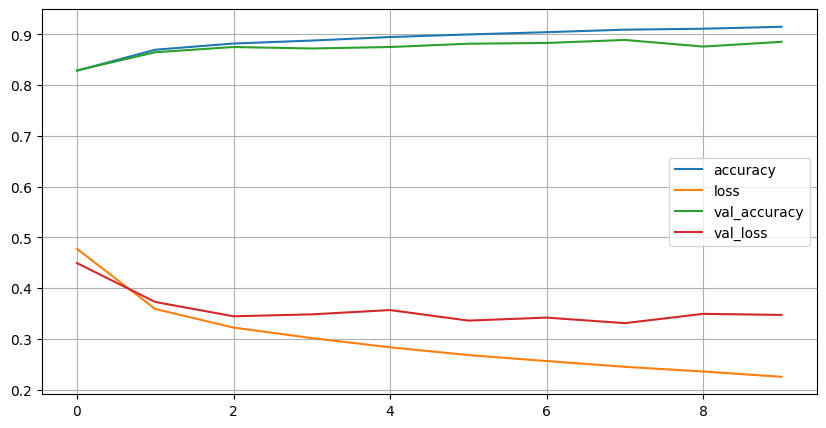

In [15]:
# Plot Training history
history_df=pd.DataFrame(history.history)

history_df.plot(figsize=(10, 5))

plt.grid(True)
plt.show()

In [16]:
# Evaluate Model
loss, accuracy=model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 574us/step - accuracy: 0.8852 - loss: 0.3470
Test Loss: 0.34698978066444397
Test Accuracy: 0.885200023651123


In [17]:
# Make Prediction
y_probs = model.predict(X_test)

y_pred = np.argmax(y_probs, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 434us/step


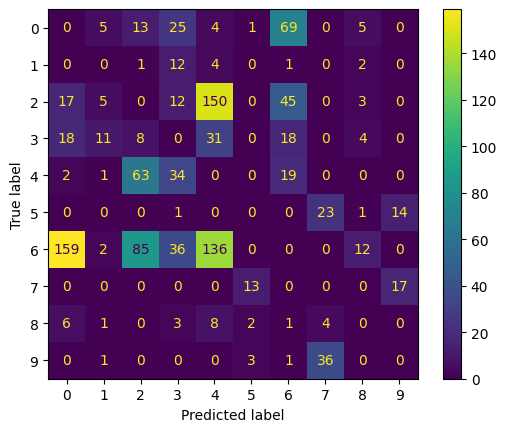

In [18]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, sample_weight= y_pred != y_test)
ConfusionMatrixDisplay(cm).plot()
plt.show()

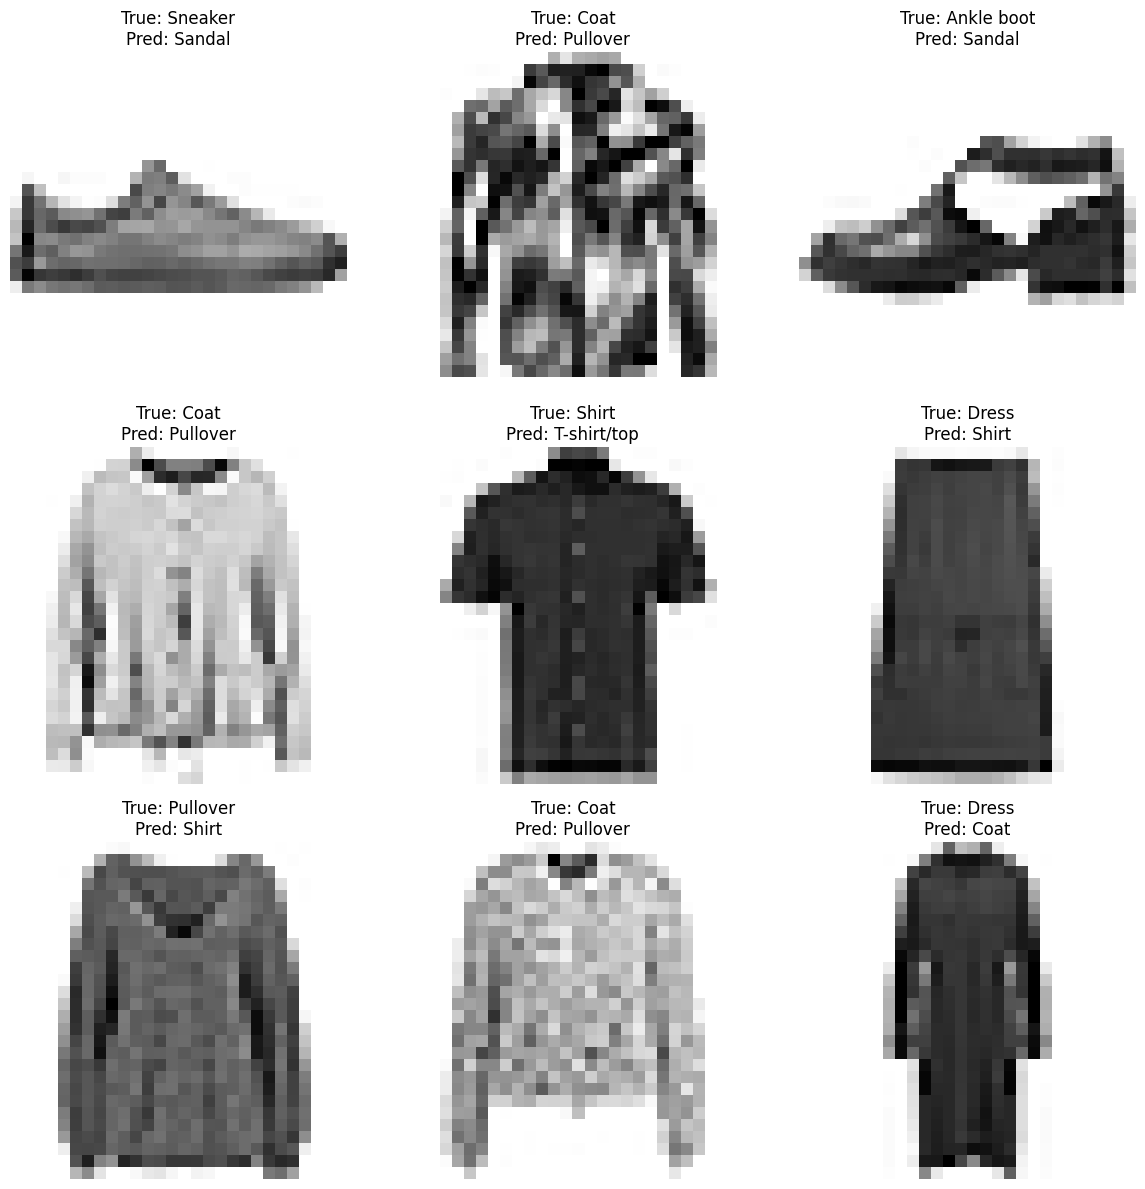

In [19]:
# Show Some Wrong Predictions
plt.figure(figsize=(12, 12))
wrong_indexes = np.where(y_pred != y_test)[0]

for i, idx in enumerate(wrong_indexes[:9]):
    
    plt.subplot(3, 3, i + 1)
    
    plt.imshow(X_test[idx], cmap='binary')
    
    plt.title(
        f"True: {class_names[y_test[idx]]}\n"
        f"Pred: {class_names[y_pred[idx]]}"
    )
    
    plt.axis('off')

plt.tight_layout()
plt.show()